# Adjoint Method

Auto-differentiation simplifies programming gradient-based optimization for solving transcripted optimal control problems. The transcription requires to discretize the time horizon and turn the differential dynamics $\dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{u})$ to a set of constraints on discretized time steps. Direct shooting uses explicit euler integration to eliminate the constraints but requires a small time interval $\delta t$ for integration accuracy. In fact, more severe issues may happen if one is careless about choosing $\delta t$. 

For the example of the three-link robot, we can simulate its free motion under the gravity with an initial configuration from a higher position. Note the initial joint position of $q_0$ is different from the previous example.

In [1]:
import os
os.environ['SIRL_USE_JAX'] = "1"
from articulated_dynamics.math_utils import nplib, rotate
from articulated_dynamics.dynamics import Dynamics, Kinematics
from articulated_dynamics.robots import ThreeLinks
from articulated_dynamics.integrator import integrate_euler
import jax

robot = ThreeLinks()

q0 = nplib.array([-nplib.pi/4, 0, 0])   #starting from a different location now!!!
qd0 = nplib.zeros(3)
x_goal = nplib.array([0.5, 0.5, 0])

@jax.jit
def simulate(init, u_traj, dt):
    tol_cost = 0

    def sim_step(carry, ctrl):
        q, qd, cumcost = carry
        qdd = Dynamics.forward(robot, q, qd, ctrl)
        q_next, qd_next = integrate_euler(robot, dt, q, qd, qdd, symplectic=True)
        x_pose = Kinematics._forward_pos(robot, q_next)[0][-1]
        #get tip position
        xp_tip = x_pose.trans + rotate(nplib.array([0, 0.15, 0]), x_pose.rot)
        cumcost += nplib.sum(nplib.abs(xp_tip - x_goal))
        return (q_next, qd_next, cumcost), (q_next, qd_next)
    
    carry_init = (init[0], init[1], tol_cost)

    carry_final, sim_traj = jax.lax.scan(sim_step, carry_init, u_traj)
    return carry_final, sim_traj



We use the explicit Euler integrator again and simulate the system with different $\delta t$, e.g. $\delta t = 0.001$, $0.005$ or $0.01$. 

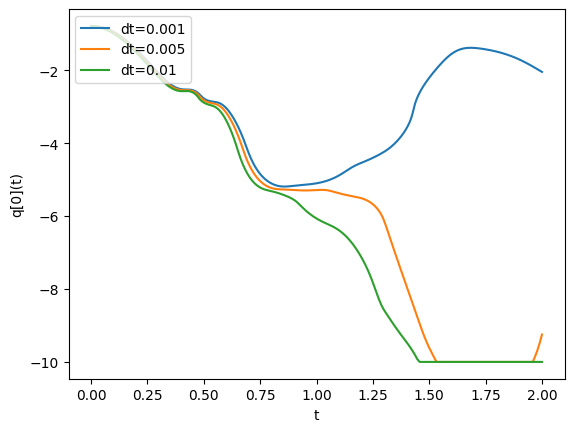

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(111)
ax = fig.add_subplot(111)

dt_lst = [0.001, 0.005, 0.01]
q0_traj = {}
for dt in dt_lst:
    T = int(2./dt)  #for 2 seconds
    u_traj = nplib.zeros((T, 3))
    final, traj = simulate((q0, qd0), u_traj, dt)
    q0_traj[dt] = traj[0]
    t = nplib.linspace(0, 2, T)
    #print(nplib.clip(traj[0][:, 0], -10, 10))
    ax.plot(t, nplib.nan_to_num(nplib.clip(traj[0][:, 0], -10, 10), nan=10), label="dt={0}".format(dt))

ax.set_xlabel('t')
ax.set_ylabel('q[0](t)')
ax.legend(loc='upper left')
plt.show()

The results in the above figure show that the simulated trajectory is not even stable. Note the deviation could have been way worse becasue the post-processing clipped extremely large or `nan` values for visualization. 

In general, explicit Euler integration like $q(t+\delta t) = q(t) + \dot{q}(t)\delta t$ can be erroneuous when the interval is large, see the image below. In this specific case, the robot links start dropping from a higher location so larger velocities are resulted from more energy. Adding larger velocity with a crude time step like $\delta t = 0.005$ or $\delta t = 0.01$ will quickly make the position value explode. 

```{figure} ../images/explicit_euler_error.png
---
height: 300px
name: expliciteuler_err
---
Larger error might be caused by using a larger interval to approximate the function evaluation with a linear extrapolation. 
```

More sophisticated integration techniques like [Runge-Kutta methods](https://en.wikipedia.org/wiki/Runge–Kutta_methods) will give a higher order accuracy. Still, a small $\delta t$ is often preferred for integration stability and precision. 
This raises an issue about using reverse-mode auto-differentiation for gradient evaluation. Recall that reverse-mode needs to store all intermediate variables of the computation graph. A very fine integration step will create lots of memory footprint because more recursions are now needed to reach the terminal time step. In the three-link example above, $\delta t = 0.001$ for $T = 2$ seconds means a 2000-step time horizon. The situation could be more dire if we need to simulate many degrees-of-freedom over a much longer time span.

Implicit Euler integration will give better stability and hence allow for using a larger $\delta t$. Basically, implicit Euler approximates the differentiation backwardly with $\dot{q}(t+\delta t) = \frac{q(t+\delta t) - q(t)}{\delta t}$. Hence the discrete-time equation can be written as:

$$
\begin{aligned}
q(t+\delta t) & = q(t) + \dot{q}(\textcolor{red}{t+\delta t}){\delta t} \\
\dot{q}(t+\delta t) & = \dot{q}(t) + \mathbf{M}^{-1}(q(\textcolor{red}{t+\delta t}))(\mathbf{u} - \mathbf{C}(q(\textcolor{red}{t+\delta t}), \dot{q}(\textcolor{red}{t+\delta t}))) \delta t
\end{aligned}
$$

Note that the right-hand sides are dependent on the next time step, making $\mathbf{x}(t + \delta t) = [q(t + \delta t), \dot{q}(t + \delta t)]^\top$ now _implicitly_ determined by the equations. We see that this indeed helps to stabilize the integration, e.g. for $\delta t = 0.005$.

In [3]:
from articulated_dynamics.integrator import _jintpos_sys
from functools import partial

def dynequ_residual(sys, dt, q, qd, tau, qd_next):
    q_next = _jintpos_sys(sys, dt, q, qd_next)
    qdd = Dynamics.forward(sys, q_next, qd_next, tau)   
    return qd+qdd*dt - qd_next

def newton_raphson(residual, init_guess, tol=1e-8, max_itr=100):
    def cond_fn(state):
        res, _, _, i = state
        return (nplib.linalg.norm(res) > tol) & (i < max_itr)
    
    def body_fn(state):
        _, _, x, i = state
        res = residual(x)
        jac = jax.jacfwd(residual)(x)
        x_next = x - nplib.linalg.solve(jac, res)
        return (res, jac, x_next, i+1)
    
    state_init = (nplib.full_like(init_guess, 100), nplib.zeros(init_guess.shape[:-1]+(init_guess.shape[-1], init_guess.shape[-1])), init_guess, 0)
    _, jac_x_star, x_star, _ = jax.lax.while_loop(cond_fn, body_fn, state_init)
    return x_star, jac_x_star

@partial(jax.custom_vjp, nondiff_argnums=(0, 1))
def integrate_implicit(sys, dt, q, qd, tau):
    qd_next, _ = integrate_implicit_fwd(sys, dt, q, qd, tau)
    return qd_next

def integrate_implicit_fwd(sys, dt, q, qd, tau):
    qd_next, drdqd_next = newton_raphson(lambda qd_next: dynequ_residual(sys, dt, q, qd, tau, qd_next), qd)
    return qd_next, (q, qd, tau, qd_next, drdqd_next)

def integrate_implicit_bwd(sys, dt, res, g):
    q, qd, tau, qd_next, drdqd_next = res
    #g@(dr/dq)^{-1}
    jac_t = nplib.swapaxes(drdqd_next, -1, -2)
    v = nplib.linalg.solve(jac_t, g)
    _, jvp_q = jax.vjp(lambda q: dynequ_residual(sys, dt, q, qd, tau, qd_next), q)
    _, jvp_qd = jax.vjp(lambda qd: dynequ_residual(sys, dt, q, qd, tau, qd_next), qd)
    _, jvp_tau = jax.vjp(lambda tau: dynequ_residual(sys, dt, q, qd, tau, qd_next), tau)
    return -jvp_q(v)[0], -jvp_qd(v)[0], -jvp_tau(v)[0]

integrate_implicit.defvjp(integrate_implicit_fwd, integrate_implicit_bwd)

In [4]:
def simulate_implicit(init, u_traj, dt):
    tol_cost = 0

    def sim_step(carry, ctrl):
        q, qd, cumcost = carry
        qd_next = integrate_implicit(robot, dt, q, qd, ctrl)
        q_next = _jintpos_sys(robot, dt, q, qd_next)

        x_pose = Kinematics._forward_pos(robot, q_next)[0][-1]
        #get tip position
        xp_tip = x_pose.trans + rotate(nplib.array([0, 0.15, 0]), x_pose.rot)
        cumcost += nplib.sum(nplib.abs(xp_tip - x_goal))
        return (q_next, qd_next, cumcost), (q_next, qd_next)
    
    carry_init = (init[0], init[1], tol_cost)

    carry_final, sim_traj = jax.lax.scan(sim_step, carry_init, u_traj)
    
    return carry_final, sim_traj

dt = 0.005
u_traj = nplib.zeros((int(2./dt), 3))
final, traj = simulate_implicit((q0, qd0), u_traj, dt)

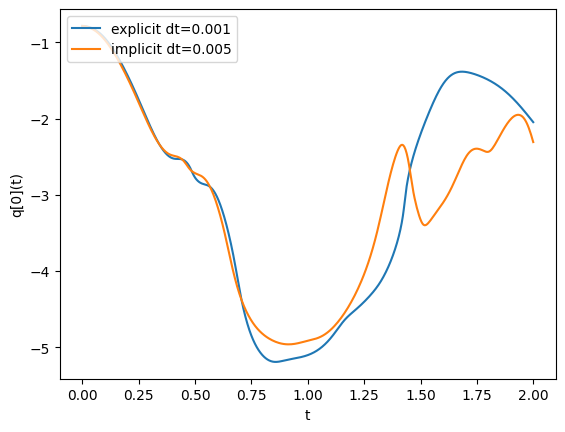

In [5]:
fig = plt.figure(111)
ax = fig.add_subplot(111)
#note numerical damping due to backward Euler?
ax.plot(nplib.linspace(0, 2, 2000), q0_traj[0.001][:, 0], label="explicit dt={0}".format(0.001))
ax.plot(nplib.linspace(0, 2, int(2./dt)), traj[0][:, 0], label="implicit dt={0}".format(dt))

ax.set_xlabel('t')
ax.set_ylabel('q[0](t)')
ax.legend(loc='upper left')
plt.show()

The function `integrate_implicit` basically solves the implicit Euler equation for the integrated state. To do this, we can use relevant software packages, such as [scipy](https://docs.scipy.org/doc/scipy/reference/optimize.html), or write our own implementation of rootfinding methods such as [Newton-Raphson](https://en.wikipedia.org/wiki/Newton%27s_method). To make this compatible to gradient-based optimal control, we need to differentiate this computation process. However, third-party software like `scipy` may not be written with a numerical system supporting auto-differentiation like `jax.numpy`. Even everything is re-written with the support, differentiating the process might still be memory intensive as the computation often involves many iteration steps as in Newton-Raphson so all intermdiate variables need to be stored in reverse-mode differentiation. This may eclipse the benefit of using a larger $\delta t$ for fewer time steps. Adjoint method is a way to alleviate these issues. 

:::{note}
Implicit Euler integration is stable while stability does not necessarily translate to precision. Actually, it introduces [numerical damping](https://scicomp.stackexchange.com/questions/14671/what-is-numerical-damping-in-the-context-of-time-dependent-fem-solvers) which artifically drags down the system velocity. That results in energy dissipation due to the choice of integrator.
:::

## Differentiating through an Implicit Process

Adjoint method concerns differentiation between variables, whose relations are not explicit like $q(t+\delta t) = q(t) + \dot{q}(t)\delta t$. In general, consider a variable $x$ and a parameter $p$, for which the dependency between $x$ and $p$ is implicitly determined through an equation:

$$
F(x, p) = 0
$$

We would like to evaluate $\frac{\partial x}{\partial p}$, or more specifically $\frac{d l}{d p} = \frac{\partial l}{\partial x} \frac{\partial x}{\partial p} + \frac{\partial l}{\partial p}$ with $l(x, p):\rightarrow \mathbb{R}$ for solving

$$
\begin{split}
& \arg\min\limits_{p} l(x, p) \\
\text{s.t.} & F(x, p) = 0
\end{split}
$$

One may find that optimal control problem is a special case of this with $x$ representing the state trajectory and $p$ for the control. The constraint is the implicit integration of the system dynamics. If we use $F = 0$ to frame the one-step implicit integration, the next-step variable to solve is $x$ here and all other variables like $q(t)$, $\dot{q}(t)$, $\mathbf{u}$ and robot model parameters are parameter $p$. The solver, whatever we choose to use, will of course yield a solution $x^*$ depending on $p$, making the value of $F$ depend on $p$ in the end, i.e. $F(x^*(p), p) = 0$. One can thus follow [the implicit function theorem](https://en.wikipedia.org/wiki/Implicit_function_theorem) and differentiate both sides:

$$
\begin{split}
& \frac{d F}{d p} = \frac{\partial F}{\partial x}\frac{\partial x}{\partial p} + \frac{\partial F}{\partial p} = 0 \\
\Rightarrow & \frac{\partial x}{\partial p} = - (\frac{\partial F}{\partial x})^{-1}\frac{\partial F}{\partial p}
\end{split}
$$

Substituting this back to the gradient of the above problem, we will obtain (adjoint method):
$$
\begin{split}
\frac{d l}{d p} & = \frac{\partial l}{\partial x} \frac{\partial x}{\partial p} + \frac{\partial l}{\partial p} \\
& = \frac{\partial l}{\partial p} \underbrace{- \frac{\partial l}{\partial x}(\frac{\partial F}{\partial x})^{-1}}_{\lambda^{\top}}\frac{\partial F}{\partial p}
\end{split}
$$

This gives a way of computing the gradient with respect to the parameter $p$ without the need of knowing how $x$ is computed. The core is to compute the Vector-Jacobian-Product of $-\frac{\partial l}{\partial x}(\frac{\partial F}{\partial x})^{-1}$ yielding a vector $\lambda$ called _adjoint_ variable, which is then used for the other Vector-Jacobian-Product computation with $\frac{\partial F}{\partial p}$. The Jacobian $\frac{\partial F}{\partial x}$ needs to be non-singular at $x^*$ for $F(x^*, p) = 0$.

## Implementation of Adjoint Method
Computing the adjoint method is straightforward by evaluating $\frac{\partial l}{\partial p}$, $\frac{\partial l}{\partial x}$, $\frac{\partial F}{\partial p}$ and $\frac{\partial F}{\partial x}$ since we have the explicit form of $F(x, p)$. The equation $F(x^*, p) = 0$ should hold but not necessarily when $x \neq x^*$. We say $F(x, p)$ yields a _residual_ and the solver essentially finds $x^*$ by shrinking the residual to $0$. 

A closer look at the shape of $\frac{\partial l}{\partial p}$ and $\frac{\partial l}{\partial x}$ will find that they are gradients (1-row Jacobian) so can be efficiently evaluated with reverse-mode auto-differentiation. There is also no need to explicitly evaluate $\frac{\partial F}{\partial p}$ with forward-mode auto-differentiation. The calculation involving the adjoint variable $\lambda$ forms another Vector-Jacobian-Product which can be efficiently evaluated with things like [`jax.vjp`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vjp.html). 

The main difficulty now boils down to calculating $\frac{\partial F}{\partial x}$ for the adjoint variable $\lambda$. Actually this is not needed because $\frac{\partial F}{\partial x}$ is often part of solving $x^*$ for $F(x^*, p) = 0$ in the forward process. We may just pass the last evaluation $\frac{\partial F}{\partial x} |_{x=x^*}$ to the backward process. To see this, consider the process of [Newton-Raphson](https://en.wikipedia.org/wiki/Newton%27s_method) method:

$$
x_{k+1} = x_k - (\frac{\partial F}{\partial x} |_{x=x_k})^{-1}F(x_k, p)
$$
which is a [fixed-point iteration](https://en.wikipedia.org/wiki/Fixed-point_iteration) process that hopefully gives us $x_k \rightarrow x^*$ as $k \rightarrow \infty$. We can expect the forward process converges at $x^*$ and thus gives the backward process $\frac{\partial F}{\partial x} |_{x=x^*}$ for free. With all that in mind, a _differentiable_ `integrate_implicit` can be implemented as following:

```python
from articulated_dynamics.integrator import _jintpos_sys
from functools import partial

def dynequ_residual(sys, dt, q, qd, tau, qd_next):
    q_next = _jintpos_sys(sys, dt, q, qd_next)
    qdd = Dynamics.forward(sys, q_next, qd_next, tau)   
    return qd+qdd*dt - qd_next

def newton_raphson(residual, init_guess, tol=1e-8, max_itr=100):
    def cond_fn(state):
        res, _, _, i = state
        return (nplib.linalg.norm(res) > tol) & (i < max_itr)
    
    def body_fn(state):
        _, _, x, i = state
        res = residual(x)
        jac = jax.jacfwd(residual)(x)
        x_next = x - nplib.linalg.solve(jac, res)
        return (res, jac, x_next, i+1)
    
    state_init = (nplib.full_like(init_guess, 100), nplib.zeros(init_guess.shape[:-1]+(init_guess.shape[-1], init_guess.shape[-1])), init_guess, 0)
    _, jac_x_star, x_star, _ = jax.lax.while_loop(cond_fn, body_fn, state_init)
    return x_star, jac_x_star

@partial(jax.custom_vjp, nondiff_argnums=(0, 1))
def integrate_implicit(sys, dt, q, qd, tau):
    qd_next, _ = integrate_implicit_fwd(sys, dt, q, qd, tau)
    return qd_next

def integrate_implicit_fwd(sys, dt, q, qd, tau):
    qd_next, drdqd_next = newton_raphson(lambda qd_next: dynequ_residual(sys, dt, q, qd, tau, qd_next), qd)
    return qd_next, (q, qd, tau, qd_next, drdqd_next)

def integrate_implicit_bwd(sys, dt, res, g):
    q, qd, tau, qd_next, drdqd_next = res
    #g@(dr/dq)^{-1}
    jac_t = nplib.swapaxes(drdqd_next, -1, -2)
    v = nplib.linalg.solve(jac_t, g)
    _, jvp_q = jax.vjp(lambda q: dynequ_residual(sys, dt, q, qd, tau, qd_next), q)
    _, jvp_qd = jax.vjp(lambda qd: dynequ_residual(sys, dt, q, qd, tau, qd_next), qd)
    _, jvp_tau = jax.vjp(lambda tau: dynequ_residual(sys, dt, q, qd, tau, qd_next), tau)
    return -jvp_q(v)[0], -jvp_qd(v)[0], -jvp_tau(v)[0]

integrate_implicit.defvjp(integrate_implicit_fwd, integrate_implicit_bwd)
```

Generally we can define the forward and backward process in `jax` or other auto-differentiation systems to override the computation of derivatives. The function call `integrate_implicit` is just a wrapper of the forward process. The backward process literally computes the adjoint variables for differentiating the input of the forward process from $\frac{d l}{d q(t+\delta t)}$. See the [document](https://jax.readthedocs.io/en/latest/notebooks/Custom_derivative_rules_for_Python_code.html) for more about doing this in `jax`. 

Now we can use the same optimal control shooting to solve the reaching problem, with the robot dynamics integrated implicitly:

In [6]:
dt = 0.005

@jax.jit
def traj_cost(u_traj_flatten):
    u_traj = u_traj_flatten.reshape((-1, 3))
    final, sim_traj = simulate_implicit((q0, qd0), u_traj, dt)
    
    #penalize aggressive control input and excessive joint velocity
    tol_cost = final[2] + nplib.sum(nplib.abs(u_traj)) * 1e-3 + nplib.sum(nplib.abs(sim_traj[1])) * 1e-2
    return tol_cost

T=int(0.5/dt) #0.5 sec
u_traj = nplib.zeros((T*3))

trajgrad = jax.grad(traj_cost)
jit_trajgrad = jax.jit(trajgrad)

print("Initial guess cost:", traj_cost(u_traj))

Initial guess cost: 68.619675


In [7]:
import scipy
import articulated_dynamics.visualizer as viz
from jax import random

u_traj = nplib.zeros(T*3) 
result = scipy.optimize.minimize(traj_cost, u_traj, method="L-BFGS-B", jac=jit_trajgrad, 
                                 options={"maxiter":1000, "disp":False, 'maxls': 20, 'eps': 1e-08, 'gtol': 1e-05, 'ftol': 1e-06})
print(result)



/var/folders/hw/6s4lhjhx1j36k7xqcfrcbpp80000gn/T/ipykernel_73319/785026851.py:6: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = scipy.optimize.minimize(traj_cost, u_traj, method="L-BFGS-B", jac=jit_trajgrad,


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 13.713053703308105
        x: [ 1.138e+01 -3.347e+00 ... -3.640e-01 -2.253e-01]
      nit: 447
      jac: [ 3.525e-02 -3.724e-02 ... -1.239e-03  5.659e-04]
     nfev: 590
     njev: 590
 hess_inv: <300x300 LbfgsInvHessProduct with dtype=float64>


In [8]:
_, sim_traj = simulate_implicit((q0, qd0), result.x.reshape((-1, 3)), dt)

viewer = viz.P3JSViewer(width=300, height=400)
viewer.create_shapes(robot)
viewer.place_shapes_qpos(robot, q0)
viewer.place_marker('goal', x_goal, scale=0.05)

#visualize the optimal trajectory, slow down the animation with 10x
anim_action = viewer.animate_qpos_traj(robot, sim_traj[0], dt*10)
viewer.show()
anim_action


Renderer(camera=PerspectiveCamera(aspect=0.75, children=(DirectionalLight(color='white', intensity=0.6, positi…

AnimationAction(clip=AnimationClip(duration=5.0, tracks=(VectorKeyframeTrack(name='scene/link_0.position', tim…

## More on Adjoint Method and Relevant Software
Adjoint method resembles lots of similarity to the reverse-mode auto-differentiation for computing $\frac{dl}{dp}$ from $\frac{\partial l}{\partial x}$, which reverses the process of computing $x^*(p): p \rightarrow x$. Actually it alleviates the memory cost of basic reverse-mode by running a nested forward process. One may notice that the implementation above calls `linalg.solve` to obtain $\lambda$ with $\lambda^\top\frac{\partial F}{\partial x}=-\frac{\partial l}{\partial x}$. This is actually yet another rootfinding problem that can also be solved with the Newton-Raphson method. The difference here is that, the equation is linear so there is no need to evaluate the Jacobian every iteration. Such a perspective gives a general scheme to mix forward-mode and reverse-mode computation to balane the time and memory costs: one may choose to not store the  intermediate variables in a segment of the computation graph, but running a forward process inside reverse-mode to recompute the variables when they are needed. Due to these rich connections, one may find the term of adjoint method sometimes refer to different things in various domains.

The fact that $\lambda$ is named adjoint variable and computed via the adjoint method may ring a bell on its relation to the Pontryagin's maximum principle. When we consider $x$ as a trajectory of $[\mathbf{x}_0, \mathbf{x}_1, ..., \mathbf{x}_T]$ and the loss $l$ is the summation of a running cost $l(\mathbf{x}_k, \mathbf{u}_k)$, the optimal control problem becomes:

$$
\begin{split}
& \arg\min\limits_{\mathbf{u}_{0:T-1}} \sum\limits_{k=0}^{T-1}l(\mathbf{x}_k, \mathbf{u}_k) \\
\text{s.t.} & F(\mathbf{x}_{k+1}, \mathbf{x}_{k}, \mathbf{u}_k) = 0 \quad   k = 0, 1, ..., T-1
\end{split}
$$

Applying Lagrangian multiplers to each $F(\mathbf{x}_{k+1}, \mathbf{x}_{k}, \mathbf{u}_k) = 0$ and focusing on the derivative of the objective for $\mathbf{x}_k$, we have:

$$
\frac{\partial l(\mathbf{x}_k, \mathbf{u}_k)}{\partial \mathbf{x}_k} + \lambda_{k+1}^\top \partial_2 F(\mathbf{x}_{k+1}, \mathbf{x}_{k}, \mathbf{u}_{k}) + \lambda_{k}^\top \partial_1 F(\mathbf{x}_{k}, \mathbf{x}_{k-1}, \mathbf{u}_{k-1}) = 0
$$

where $\partial_i F$ means taking the partial derivative with respect to the $i$-th input argument. If we assume $F(\mathbf{x}_{k+1}, \mathbf{x}_{k}, \mathbf{u}_{k}) = f(\mathbf{x}_{k}, \mathbf{u}_{k}) - \mathbf{x}_{k+1}$, the above equation boils down to:

$$
\frac{\partial l(\mathbf{x}_k, \mathbf{u}_k)}{\partial \mathbf{x}_k} + \lambda_{k+1}^\top \frac{\partial f}{\partial \mathbf{x}}(\mathbf{x}_{k}, \mathbf{u}_{k}) = \lambda_{k}^\top 
$$

This is simply the discretized version of the adjoint equation in the [optimal control module](../5_OptimalControl/notebooks.ipynb#indirect-methods). The semantic meanings of adjoint state/variable are also consistent in both contexts: for computing the derivative of a total cost over the control horizon/the computation graph. The equivalence between them and the fact that we can detach forward and backward processes in adjoint method gives an implication: we can use different differential equation solvers and parameters in the optimal control's forward simulation and control derivation steps.

Adjoint method is commonly used for differentiating computation involving implicit processes, which sometimes give us greater modelling flexibility in designing machine learning models. Cases include having implicit functions as neural network layers [@deepequilibriumlayers], the ODE perspective to ResNet and flow models with continuum layers [@grathwohl2018scalable][@pointflow]. It also offers to optimize through an optimization process [@cvxpylayers2019], a.k.a. differentiable optimization,  which can be useful if stepping robot simulation needs to resolve motion constraints [@Qiao2021Efficient]. More thorough discussion can be found from [online tutorials](http://implicit-layers-tutorial.org).

Besides these scattered implementations, [jaxopt](https://github.com/google/jaxopt/tree/main/docs) and [Optax](https://github.com/google-deepmind/optax) are differentiable optimization libraries for `jax`.  [cvpylayers](https://github.com/cvxgrp/cvxpylayers) focuses on differenting convex optimization, allowing for integration with learning pipelines written by `PyTorch`, `jax` or `TensorFlow`. 

```{bibliography}
:filter: docname in docnames
```